# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.16'

In [2]:
viz = Viz(dpi=125)

<hr>

## Parameters

In [3]:
n_xy: int = 300
n_iterations: int = 20_000
p_3 = 1e-2

In [4]:
phase_diagram_expts_tuple = (
    dict(p_1=0.5383, p_2=0.9990,   p_3=0, scale=1.26),
    dict(p_1=0.5391, p_2=0.9900,   p_3=0, scale=1.26),
    dict(p_1=0.5497, p_2=0.8500,   p_3=0, scale=1.15),
    dict(p_1=0.5594, p_2=0.7000,   p_3=0, scale=0.98),
    dict(p_1=0.5671, p_2=0.5671,   p_3=0, scale=0.925),
    dict(p_1=0.5708, p_2=0.5000,   p_3=0, scale=0.89),
    dict(p_1=0.5806, p_2=0.3000,   p_3=0, scale=0.81),
    dict(p_1=0.5873, p_2=0.1500,   p_3=0, scale=0.76),
    dict(p_1=0.5934, p_2=0.0000,   p_3=0, scale=0.725),
)
phase_diagram_expts = {i: expt for i, expt in enumerate(phase_diagram_expts_tuple)}

In [5]:
p3_expts_tuple = (
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=1.276744e-06),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=1.156416e-05),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=1.229950e-04),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=1.202141e-03),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.141549e-02),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=8.502819e-02),
    dict(p_1=0.5, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=3.411415e-01),
    #
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=3.936034e-06),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=3.608598e-05),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=3.767733e-04),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=3.666900e-03),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=3.063740e-02),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=1.442286e-01),
    dict(p_1=0.55, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=3.977777e-01),
    # 
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=1.504738e-05),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=1.306045e-04),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=1.339584e-03),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=1.231168e-02),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=6.619371e-02),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=1.900987e-01),
    dict(p_1=0.575, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.286503e-01),
    # 
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=5.387214e-05),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=4.282526e-04),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=4.508136e-03),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=2.879759e-02),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=9.332287e-02),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.114318e-01),
    dict(p_1=0.585, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.414231e-01),
    # 
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=2.712881e-04),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=1.758293e-03),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=1.318895e-02),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=4.751823e-02),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.099126e-01),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.226105e-01),
    dict(p_1=0.59, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.479314e-01),
    # 
    # dict(p_1=0.59, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=2.712881e-04),
    # 
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=1.367268e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=2.087483e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=3.487083e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=6.552066e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.220608e-01),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.303522e-01),
    dict(p_1=0.5934, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.523607e-01),
    # 
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=6.611606e-02),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=6.656436e-02),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=7.004081e-02),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=8.804800e-02),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.362778e-01),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.388846e-01),
    dict(p_1=0.597, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.570666e-01),
    # 
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=9.480e-02),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=9.500e-02),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=9.620e-02),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=1.069e-01),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.476e-01),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.458e-01),
    dict(p_1=0.6, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.610e-01),
    # 
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=1.603634e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=1.604069e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=1.607907e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=1.643766e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=1.877898e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.700789e-01),
    dict(p_1=0.61, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.742828e-01),
    # 
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=2.102540e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=2.102743e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=2.104702e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=2.122575e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=2.268593e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=2.947867e-01),
    dict(p_1=0.62, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=4.877410e-01),
    # 
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-7, scale=0.725, tail_mean_ρ=3.240246e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-6, scale=0.725, tail_mean_ρ=3.240299e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-5, scale=0.725, tail_mean_ρ=3.240843e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-4, scale=0.725, tail_mean_ρ=3.246521e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-3, scale=0.725, tail_mean_ρ=3.300569e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-2, scale=0.725, tail_mean_ρ=3.693711e-01),
    dict(p_1=0.65, p_2=0.0000,   p_3=1e-1, scale=0.725, tail_mean_ρ=5.289810e-01),
)

In [6]:
grouped_by_p1_expts = {expt["p_1"]: {} for i, expt in enumerate(p3_expts_tuple)}
for i, expt in enumerate(p3_expts_tuple):
    grouped_by_p1_expts[expt["p_1"]].update({expt["p_3"]: expt})
grouped_by_p3_expts = {expt["p_3"]: {} for i, expt in enumerate(p3_expts_tuple)}
for i, expt in enumerate(p3_expts_tuple):
    grouped_by_p3_expts[expt["p_3"]].update({expt["p_1"]: expt})

expt = grouped_by_p1_expts[0.597][1e-1]
expt

{'p_1': 0.597,
 'p_2': 0.0,
 'p_3': 0.1,
 'scale': 0.725,
 'tail_mean_ρ': 0.4570666}

In [7]:
# from matplotlib.lines import Line2D
# print(Line2D.markers)
markers = {'o': 'circle', 'v': 'triangle_down', '^': 'triangle_up', '<': 'triangle_left', 
 '>': 'triangle_right', 
#  '1': 'tri_down', '2': 'tri_up', '3': 'tri_left', '4': 'tri_right',
#  's': 'square', 
 '8': 'octagon', 'p': 'pentagon', 
# '*': 'star', 
'h': 'hexagon1',
'H': 'hexagon2', 
#  '+': 'plus', 'x': 'x', 
 'D': 'diamond', 
 'd': 'thin_diamond', '|': 'vline', '_': 'hline', 
 'P': 'plus_filled', 'X': 'x_filled', 
#  0: 'tickleft', 1: 'tickright', 
#  2: 'tickup', 3: 'tickdown', 
#  4: 'caretleft', 5: 'caretright', 6: 'caretup',
#    7: 'caretdown', 8: 'caretleftbase', 9: 'caretrightbase', 10: 'caretupbase', 11: 'caretdownbase'
}

In [8]:
class Parameters:
    growth_model = GrowthModel.Bedload
    dim = Dimension.D2
    n_x: int = n_xy
    n_y: int = n_xy
    n_z: int = 1
    p_1: float = expt["p_1"]
    p_2: float = expt["p_2"]
    p_3: float = expt["p_3"]
    n_iterations: int = n_iterations
    sample_period: int = 0
    random_seed: int = 5
    # initial_condition = InitialCondition.EdgeCell
    initial_condition = InitialCondition.Randomized
    p_initial: float = 0.99
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [9]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [10]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [11]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [12]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(0,)

<hr>

## Visualization

### Phase diagram

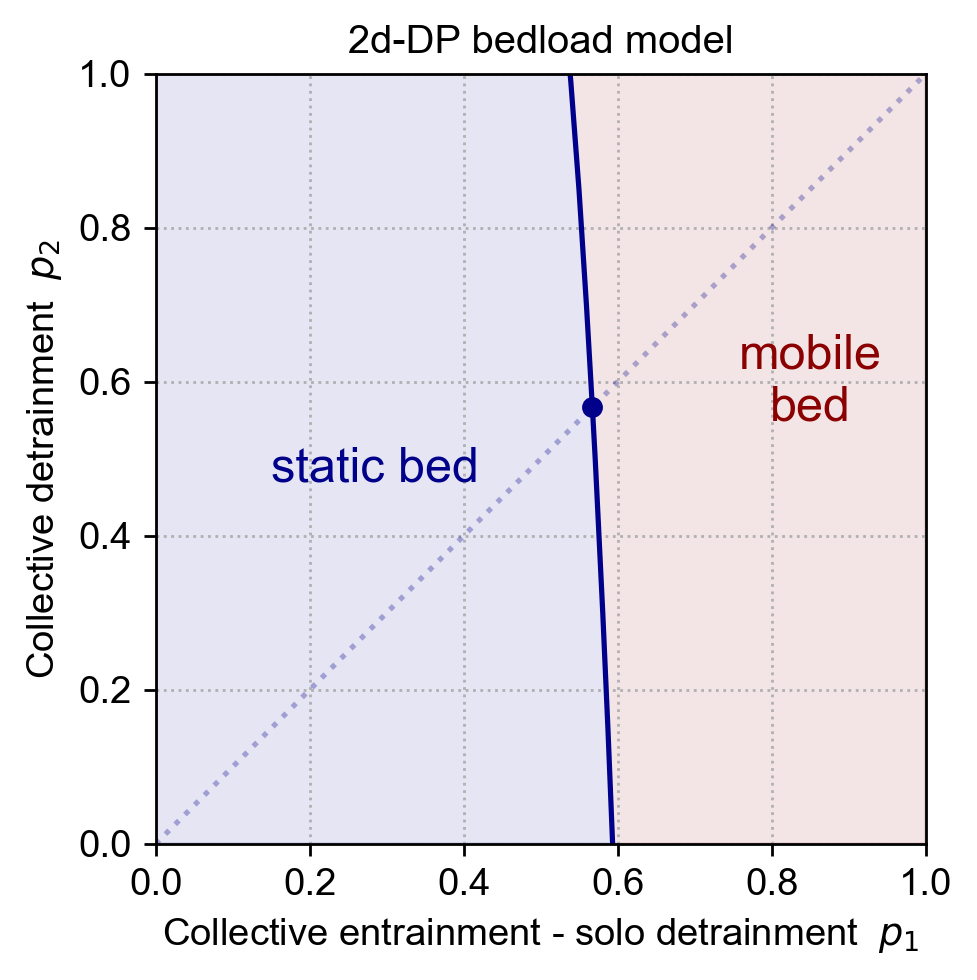

In [13]:
name: str = make_name(parameters, "phase_diagram",)
title: str = "2d-DP bedload model"
viz.phase_diagram(name, title, phase_diagram_expts, i_equal=4,)
plt.show()


### Curves

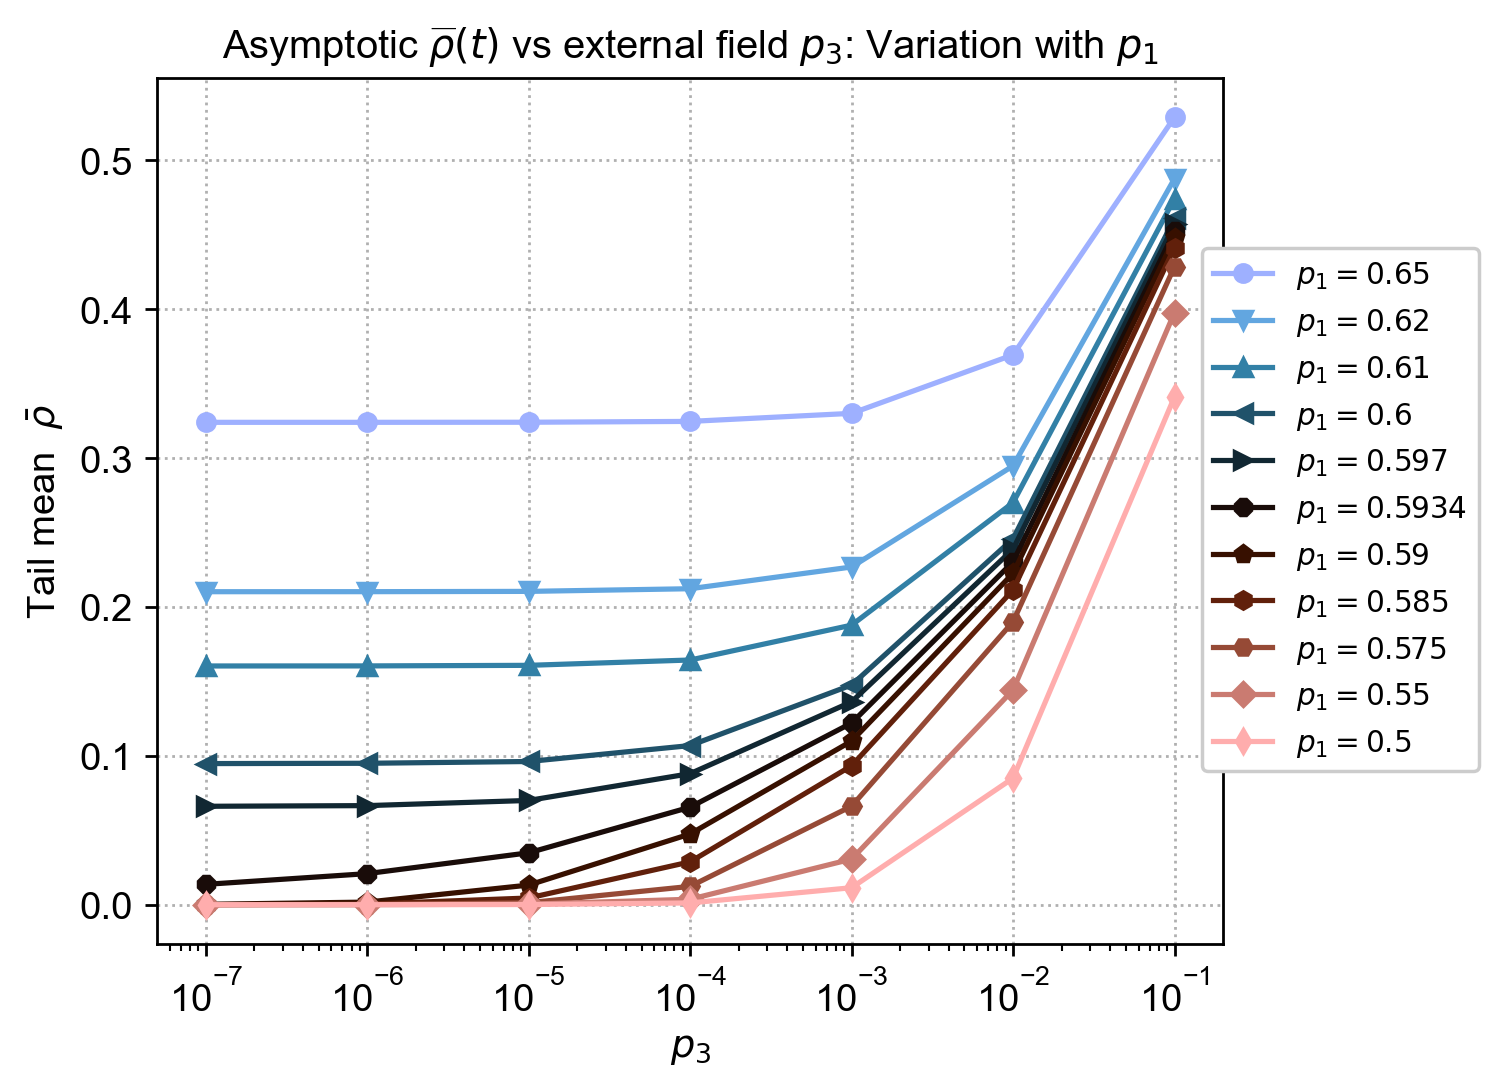

In [14]:
viz.create_figure(fig_name="", fig_size=(5.5, 4.5,),)
plt.title(
    "Asymptotic $\\widebar\\rho(t)$ vs external field $p_3$: Variation with $p_1$", 
    fontdict={"fontsize": 11.5}
)
p_1_choices = (0.5, 0.55, 0.575, 0.585, 0.59, 0.5934, 0.597, 0.6, 0.61, 0.62, 0.65,)
# color_map_name = "copper_r"
# color_map_name = "winter"
color_map_name = "coolwarm"
color_map_name = "berlin"
# color_map_name = "managua"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_1_choices)))
for (p_1, color, marker) in zip(reversed(p_1_choices), colors, markers.keys()):
    xy = np.array([(v["p_3"], v["tail_mean_ρ"]) for v in grouped_by_p1_expts[p_1].values()]).T
    plt.plot(*xy, marker=marker, ms=5, color=color, label=rf"$p_1={p_1}$")
# plt.xlim(0, 1,)
# plt.ylim(0, 1,)
plt.xlabel(r"$p_3$")
plt.ylabel(r"Tail mean  $\bar{\rho}$")
# axes = plt.gca()
# axes.set_aspect(1)
plt.semilogx()
# plt.loglog()
plt.legend(fontsize=8.5, loc=(0.98, 0.2,), framealpha=1)
plt.grid(ls=":")

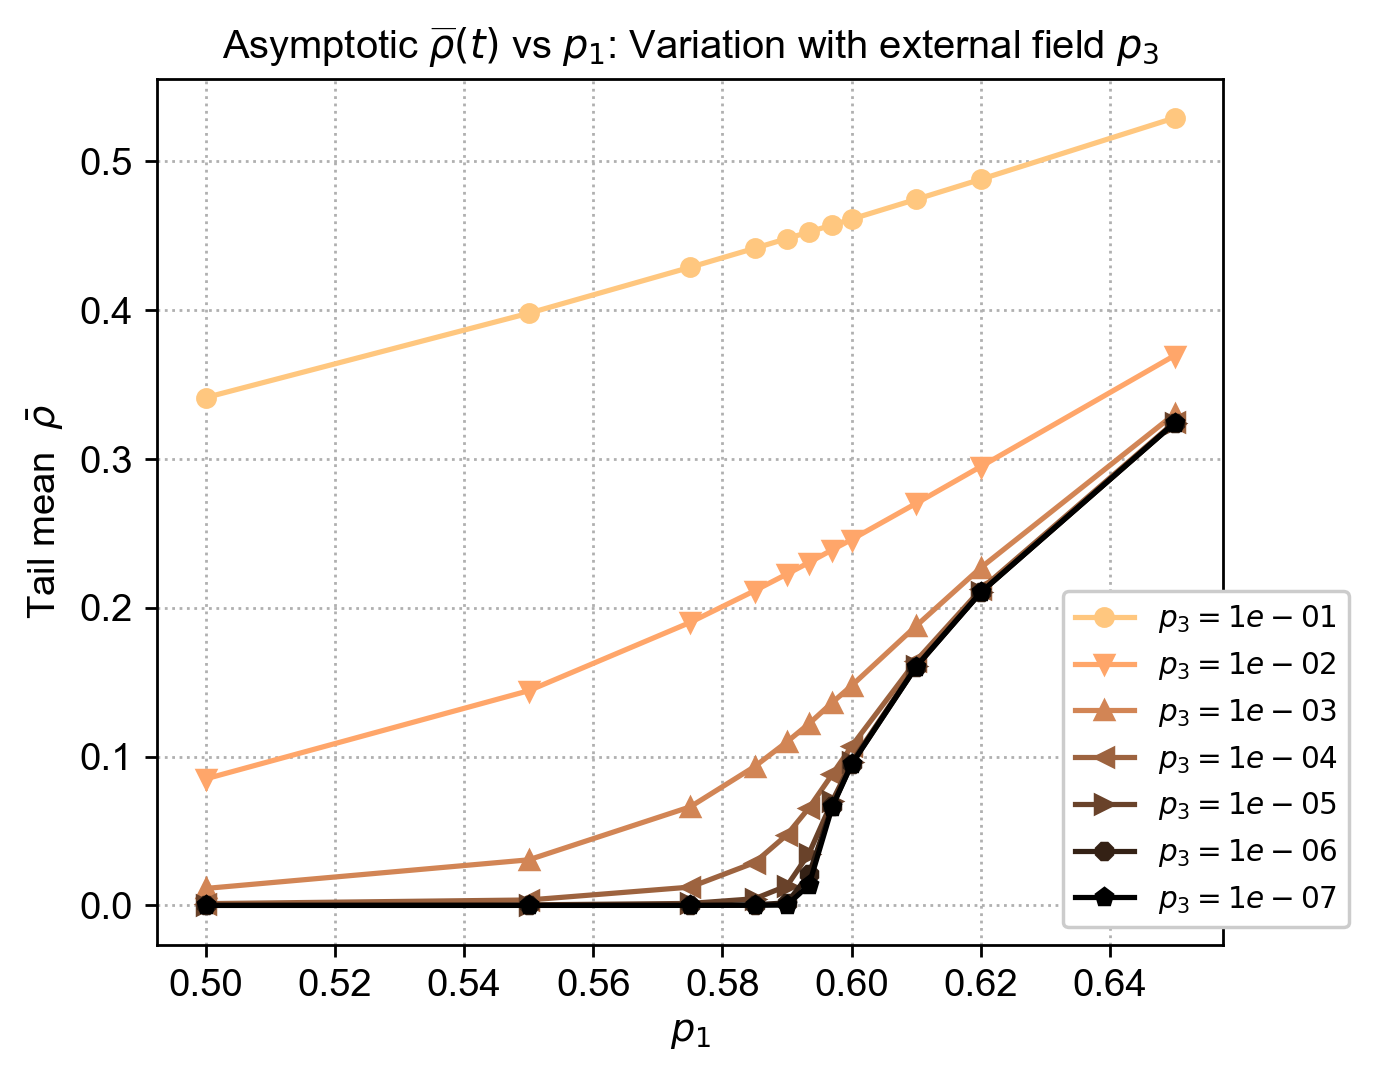

In [15]:
viz.create_figure(fig_name="", fig_size=(5.5, 4.5,),)
plt.title(
    "Asymptotic $\\widebar\\rho(t)$ vs $p_1$: Variation with external field $p_3$", 
    fontdict={"fontsize": 11.5}
)
p_3_choices = (1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,)
color_map_name = "copper_r"
# color_map_name = "winter"
# color_map_name = "coolwarm"
# color_map_name = "berlin"
# color_map_name = "managua"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_3_choices)))
for (p_3, color, marker) in zip(reversed(p_3_choices), colors, markers.keys()):
    xy = np.array([(v["p_1"], v["tail_mean_ρ"]) for v in grouped_by_p3_expts[p_3].values()]).T
    plt.plot(*xy, marker=marker, ms=5, color=color, label=rf"$p_3={p_3:0.0e}$")
# plt.xlim(0, 1,)
# plt.ylim(0, 1,)
plt.xlabel(r"$p_1$")
plt.ylabel(r"Tail mean  $\bar{\rho}$")
# axes = plt.gca()
# axes.set_aspect(1)
# plt.semilogx()
# plt.loglog()
plt.legend(fontsize=8.5, loc=(0.85, 0.02,), framealpha=1)
plt.grid(ls=":")

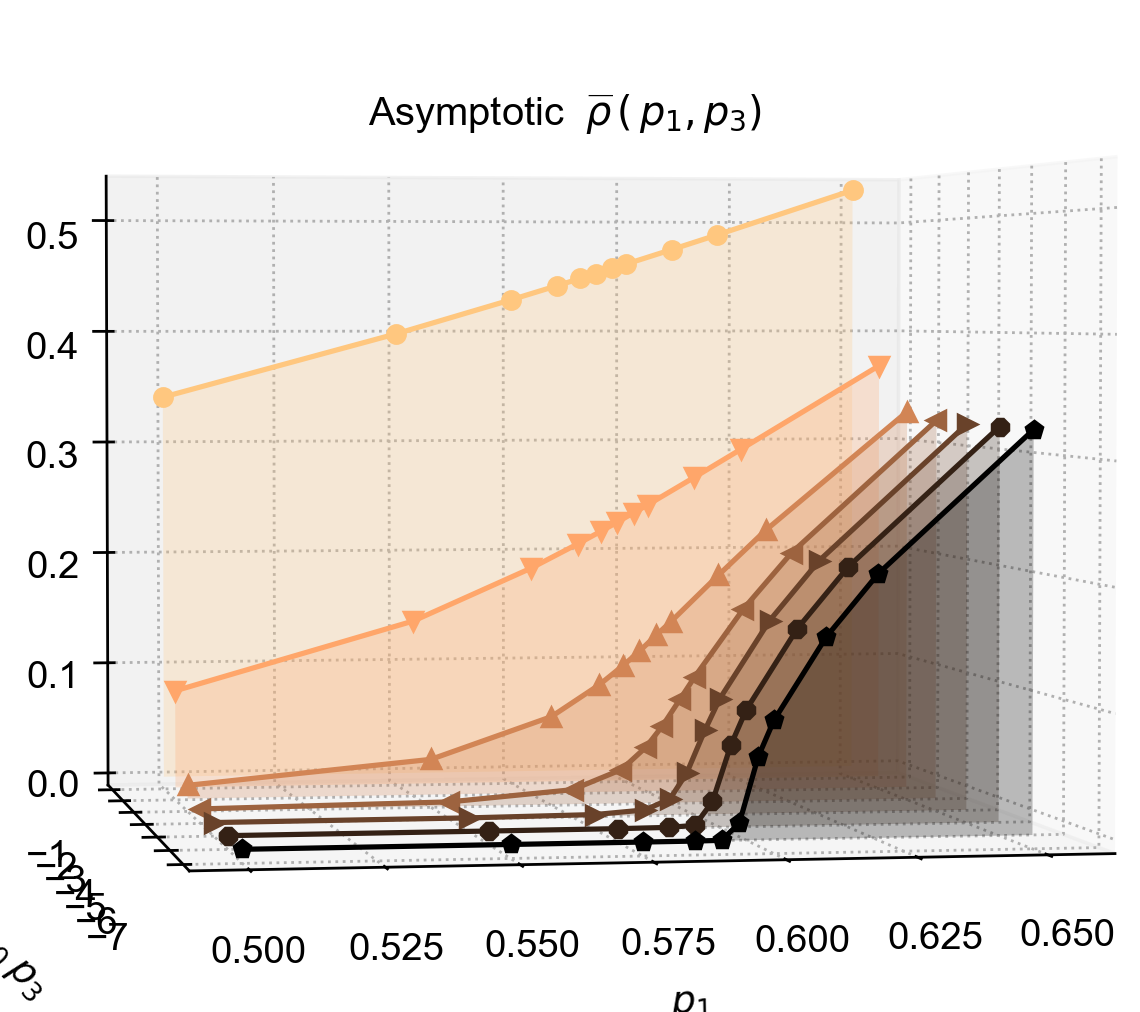

In [127]:
fig = viz.create_figure(fig_name="", fig_size=(6, 5,),)
axes = plt.axes(projection="3d", proj_type="persp",)
axes.set_title(
    "Asymptotic  $\\widebar\\rho\\,(\\,p_1, p_3)$", 
    fontdict={"fontsize": 11.5}, y=0.95,
)
p_3_choices = (1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,)
color_map_name = "copper_r"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_3_choices)))
for (p_3, color, marker) in zip(reversed(p_3_choices), colors, markers.keys()):
    xyz = np.array([(v["p_1"], np.log10(v["p_3"]), v["tail_mean_ρ"]) for v in grouped_by_p3_expts[p_3].values()]).T
    xy0 = np.array([(v["p_1"], np.log10(v["p_3"]), 0) for v in grouped_by_p3_expts[p_3].values()]).T
    axes.plot3D(*xyz, marker=marker, ms=5, color=color, label=rf"$p_3={p_3:0.0e}$", zorder=100,)
    axes.fill_between(*xyz, *xy0, facecolors=color, alpha=0.25,)
plt.xlabel(r"$p_1$")
plt.ylabel(r"$\log_{10}{p_3}$")
plt.xlim(None, 0.663)
# axes.set_zlabel(r"Tail mean  $\bar{\rho}$", labelpad=-3,)
# axes.set_zticklabels(labels=((0,0,0),0,))
axes.tick_params(axis='z', pad=1)
axes.xaxis._axinfo["grid"].update({"linestyle": ":"})
axes.yaxis._axinfo["grid"].update({"linestyle": ":"})
axes.zaxis._axinfo["grid"].update({"linestyle": ":"})
axes.view_init(elev=2., azim=-100,)
axes.set_box_aspect(None, zoom=1.4) 
# zdirs = (None, 'x', 'y', 'z', (1, 1, 0), (1, 1, 1))
# xs = (1, 4, 4, 9, 4, 1)
# ys = (2, 5, 8, 10, 1, 2)
# zs = (10, 3, 8, 9, 1, 8)

# for zdir, x, y, z in zip(zdirs, xs, ys, zs):
#     label = '(%d, %d, %d), dir=%s' % (x, y, z, zdir)
#     axes.text(x, y, z, label, zdir)


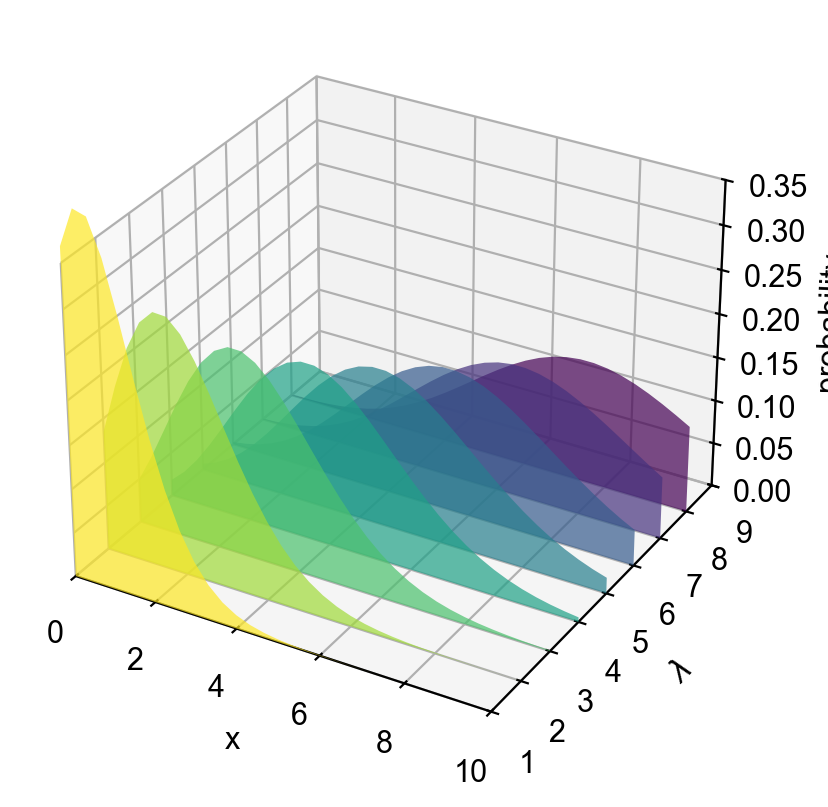

In [17]:
import math
gamma = np.vectorize(math.gamma)
N = 31
x = np.linspace(0., 10., N)
lambdas = range(1, 9)

ax = plt.figure().add_subplot(projection='3d')

facecolors = plt.colormaps['viridis_r'](np.linspace(0, 1, len(lambdas)))

for i, l in enumerate(lambdas):
    # Note fill_between can take coordinates as length N vectors, or scalars
    ax.fill_between(x, l, l**x * np.exp(-l) / gamma(x + 1),
                    x, l, 0,
                    facecolors=facecolors[i], alpha=.7)

ax.set(xlim=(0, 10), ylim=(1, 9), zlim=(0, 0.35),
       xlabel='x', ylabel=r'$\lambda$', zlabel='probability')

plt.show()

### Evolution

In [18]:
viz_lattice = partial(
    viz.lattice,
    lattices=lattices, 
    p=parameters, 
    x=min(1000, parameters.n_x),
    y=min(1000, parameters.n_y),
    fig_size=(6, 4,),
)

In [19]:
i_slice: int
if n_lattices>0:
    for i_slice in (20, 50, 100, 150, 200, 250,):
        name = make_name(parameters, "lattice", i_slice,)
        print(name)
        viz_lattice(
            name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
        )
        plt.show()

### Mean order parameter $t$-decay

ρmean_p0p597000_s5_nx300_ny300


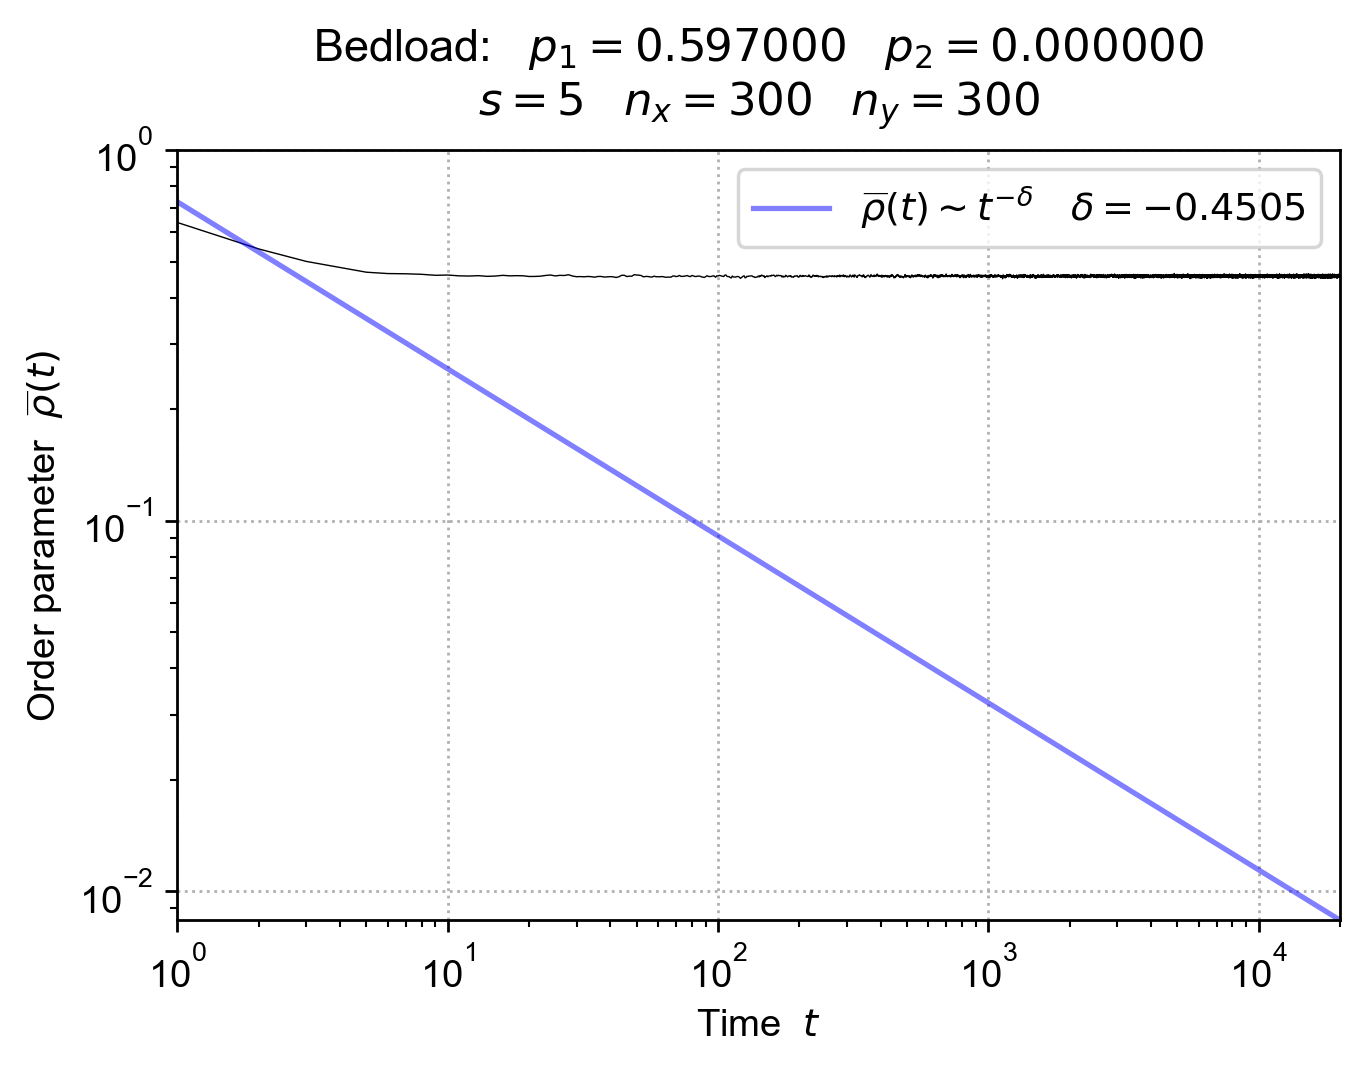

In [20]:
δ = 0.45051
scale = expt["scale"]
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=0,
    do_ref_curve=True,
)
plt.ylim(None, 1)
plt.show()

In [21]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 400.0-20000.0
Estimated t-decay exponent:  δ = -0.000


In [22]:
i_offset: int = parameters.n_iterations//5
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
mean_ρ_mean: float = np.mean(tracking["ρ_mean"][i_offset:])
print(f"t range: {t[0]}-{t[-1]}")
print(f"Tail mean: <ρ> = {(mean_ρ_mean):e}")
print(f"External:  p_3 = {(parameters.p_3):g}")
print(f"Tail mean/p3:  <ρ>/p_3 = {round(mean_ρ_mean/parameters.p_3, 1)}")

t range: 4000.0-20000.0
Tail mean: <ρ> = 4.570666e-01
External:  p_3 = 0.1
Tail mean/p3:  <ρ>/p_3 = 4.6


<hr>

## Export

In [23]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload2d'